### Example - DiscriminationThreshold visualizations

This is a very clever optimization trick, **but unfortunately it only works for BINARY CLASSIFICATION**.

This visualization allows us to optimize the correct threshold where our model should make decisions.

By default, a binary classifier uses 0.5 as the threshold for decision.

Prediction under 0.5 => negative prediction
Prediction of 0.5 or more => positive prediction

The DiscriminationThreshold provides you a new threshold that should be better optimized for your data and model!

Code example from Yellowbrick documentation:

https://www.scikit-yb.org/en/latest/api/classifier/threshold.html

c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this 

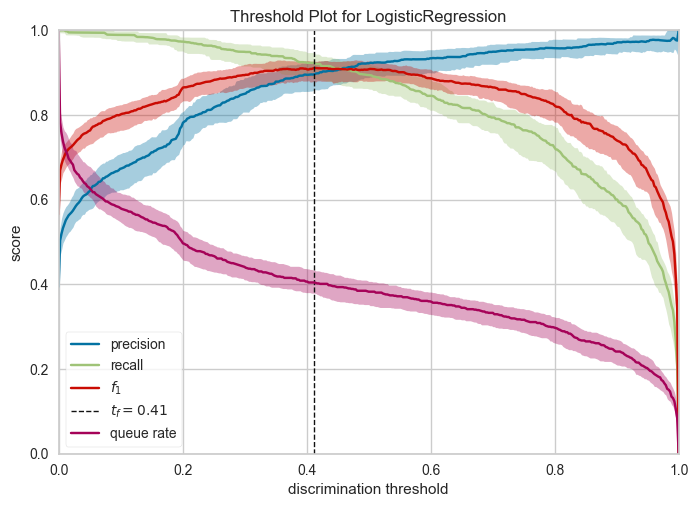

<Axes: title={'center': 'Threshold Plot for LogisticRegression'}, xlabel='discrimination threshold', ylabel='score'>

In [18]:
from sklearn.linear_model import LogisticRegression

from yellowbrick.classifier import DiscriminationThreshold
from yellowbrick.datasets import load_spam

# Load a binary classification dataset
X, y = load_spam()

# Instantiate the classification model and visualizer
model = LogisticRegression(multi_class="auto", solver="liblinear")
visualizer = DiscriminationThreshold(model)

visualizer.fit(X, y)        # Fit the data to the visualizer
visualizer.show()           # Finalize and render the figure

In [19]:
import pandas as pd
# Convert X (usually numpy array) to DataFrame
df_X = pd.DataFrame(X)

# Convert y (usually numpy array) to Series
df_y = pd.Series(y, name='target')

# Optionally, combine into a single DataFrame
df = pd.concat([df_X, df_y], axis=1)
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,target
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.000,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4596,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4597,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4598,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [20]:
# WHAT TO LOOK FOR IN ABOVE

# Precision should INCREASE as discrimination threshold increases
# Recall should DECREASE as discrimination threshold increases
# F1 score PEAKS in threshold value where precision and recall ARE BEST BALANCED
# Queue rate should go down as discrimination threshold increases
# queue rate means % of how much of data was classified positively

# vertical line or tf => suggested optimal threshold function value (defaults to maximizing f1)

In [21]:
# FROM CHATGPT:

# When Things Don’t Behave as Expected
# 1. Precision doesn't increase with threshold

# Expected behavior: As threshold ↑, model gets more conservative → precision ↑

# If not happening:

# Model may be poorly calibrated (e.g., bad probability estimates)
# Model may be random/guessing → all metrics are flat or unstable
# Severe class imbalance + few positive predictions → noisy precision

# 2. Recall doesn't decrease with threshold

# Expected behavior: As threshold ↑, model becomes pickier → recall ↓

# If not happening:

# Model is already very conservative — low recall at all thresholds
# Class imbalance so extreme that recall is always low
# Possible bug in labeling (e.g., flipped labels)

# 3. F1 score is flat or doesn’t peak

# Expected behavior: Should have a clear peak where precision & recall are balanced

# If not happening:

# Model is too weak or too confident — precision and recall not changing with threshold

# You may have:

# A very poor feature set

# Bad data splits
# Over-regularization
# A broken model pipeline (e.g., no shuffling, label leakage)

# 4. Queue rate is flat

# Expected behavior: Queue rate drops as threshold increases

# If not happening:

# Probabilities are too compressed or extreme (e.g., 0.01 or 0.99 only)
# Model outputs are not probabilistic, or thresholding isn't working as expected
# Something is wrong with the thresholding mechanism

In [22]:
# ft => threshold function value suggested value
# this is used in binary classification

# by default we classify the result by splitting the prediction at 0.5
# less than 0.5 => negative
# 0.5 or more => positive

# ft (e.g. 0.41) is a calculated suggestion where the threshold should be instead 
# SO THAT YOUR MODEL WORKS BETTER

# essentially, this threshold tries to fix the problems that ROC-AUC measures!



### Let's try this with a binary version of the lifestyle dataset

In [23]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [24]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [25]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [26]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [27]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [28]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0

df['Rating'] = df['Rating'].astype(int)

**Convert the target to binary**

In [29]:
def convert_to_binary(row):
    if row['Rating'] <= 1:
        return 0
    else:
        return 1
    

df['Rating'] = df.apply(convert_to_binary, axis=1)

In [30]:
# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['ParticipantID'], axis=1)

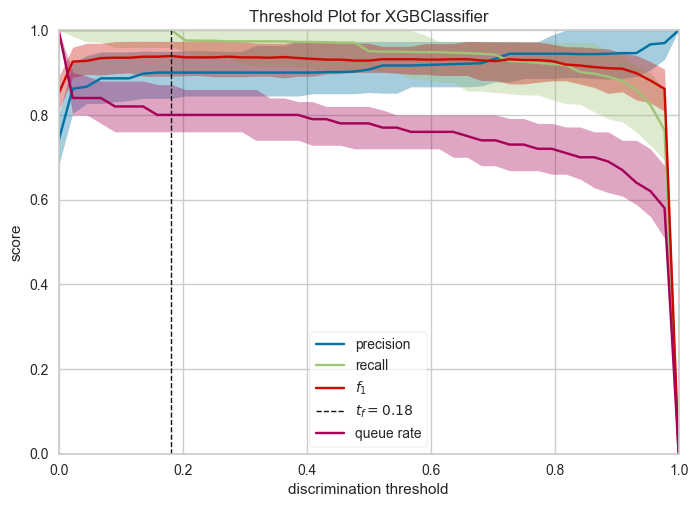

<Axes: title={'center': 'Threshold Plot for XGBClassifier'}, xlabel='discrimination threshold', ylabel='score'>

In [31]:
import xgboost as xgb
# Instantiate the classification model and visualizer
# model = LogisticRegression(multi_class="auto", solver="liblinear")

model = xgb.XGBClassifier(tree_method='gpu_hist', objective="binary:logistic")
visualizer = DiscriminationThreshold(model)

X = df.drop("Rating", axis=1)
y = df['Rating']

visualizer.fit(X, y)        # Fit the data to the visualizer
visualizer.show()           # Finalize and render the figure

In [32]:
# very wide confidence intervals this time => implies that the visualizer is uncertain of this model

# not surprising, this dataset is pretty bad without optimizations

# also ft is super low => the model has trouble differentiating between positive and negative

# the small dataset also doesn't help here...